# DSCI 633 Project
### Predicting Readmittance within 30 Days for Hospitalized Diabetes Patients  
*Michael Eaton, Rochester Institute of Technology — Fall 2025*

In [38]:
from shared_util.dataio import load_csv
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
PLOT_ID = 1 # set to the id you want to see plotted if there are more than 1 run of a model

In [49]:
df = load_csv('metrics')

df = df.reset_index()

df = df.sort_values(by='roc_auc', ascending=False)

In [50]:
df[(df['data'] == 'test') | (df['data'] == 'validate')].head(20)

,id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,TN,TP,FP,FN
2,0,rf,validate,base,under_sample,tuned_best_roc_auc,NaN,0.661655,0.624958,0.174760,0.622353,0.272891,8337.0,1058.0,4996.0,642.0
3,0,rf+int,validate,base,under_sample,tuned_best_roc_auc,NaN,0.661511,0.623894,0.173439,0.617647,0.270828,8329.0,1050.0,5004.0,650.0
4,0,rf,test,f2_weighted,under_sample,tuned_best_roc_auc,NaN,0.661281,0.533965,0.167305,0.716238,0.271250,6755.0,1310.0,6520.0,519.0
14,0,xgboost,validate,base,under_sample,tuned best F2,first pass,0.658122,0.389343,0.138158,0.840000,0.237288,4425.0,1428.0,8908.0,272.0
15,0,xgboost,test,f2_weighted,under_sample,tuned best F2,first pass,0.654761,0.392810,0.147223,0.837616,0.250429,4401.0,1532.0,8874.0,297.0
22,1,sgd,test,f2_weighted,under_sample,tuned best ROC,with log transform,0.654717,0.442664,0.152149,0.787862,0.255044,5245.0,1441.0,8030.0,388.0
9,0,sgd,test,f2_weighted,under_sample,tuned best ROC,first pass,0.652422,0.476496,0.156688,0.758338,0.259714,5810.0,1387.0,7465.0,442.0
18,1,sgd,validate,base,under_sample,tuned best roc,with log transform,0.651867,0.646977,0.175454,0.573529,0.268706,8751.0,975.0,4582.0,725.0
8,0,sgd,validate,base,under_sample,tuned best roc,first pass,0.650411,0.661545,0.175355,0.538235,0.264527,9030.0,915.0,4303.0,785.0
20,1,svc,validate,base,under_sample,tuned best roc,with log transform,0.649961,0.684694,0.180672,0.505882,0.266254,9433.0,860.0,3900.0,840.0


In [51]:
import pandas as pd

def filter_duplicates_by_id(df, keep_id):
    
    key_cols = ['model', 'data', 'threshold_notes', 'pipeline_notes']
    
    
    duplicated_mask = df.duplicated(subset=key_cols, keep=False)

    duplicates = df[duplicated_mask]
    uniques = df[~duplicated_mask]
    
    kept_duplicates = duplicates[duplicates['id'] == keep_id]
    
    result = pd.concat([uniques, kept_duplicates], ignore_index=True)
    
    return result.sort_values(by='roc_auc', ascending=False).reset_index(drop=True)





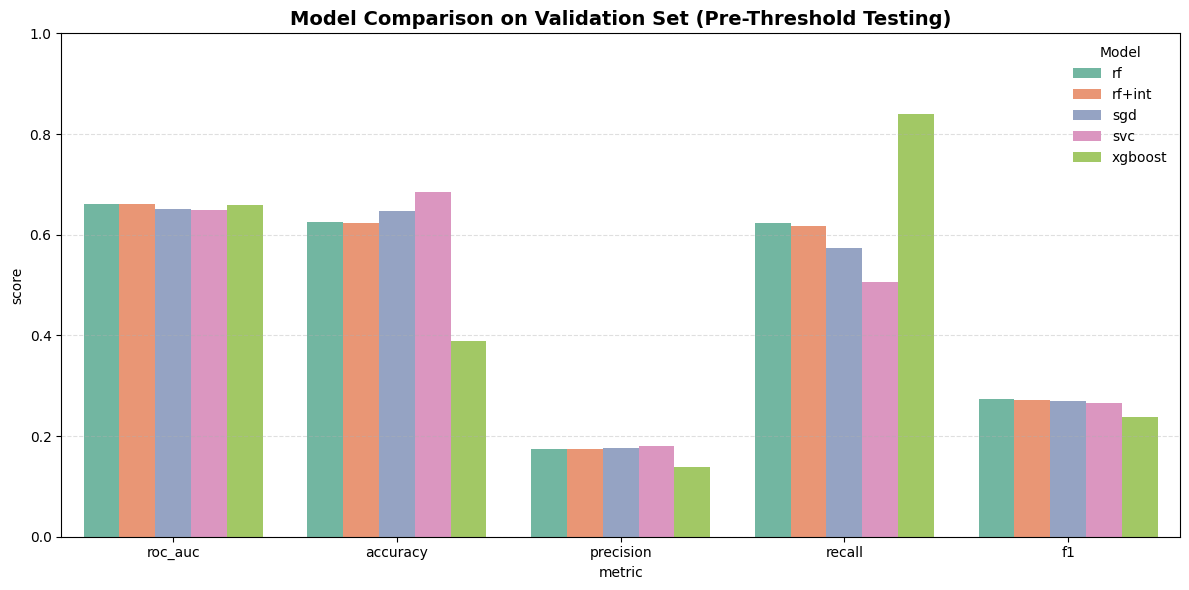

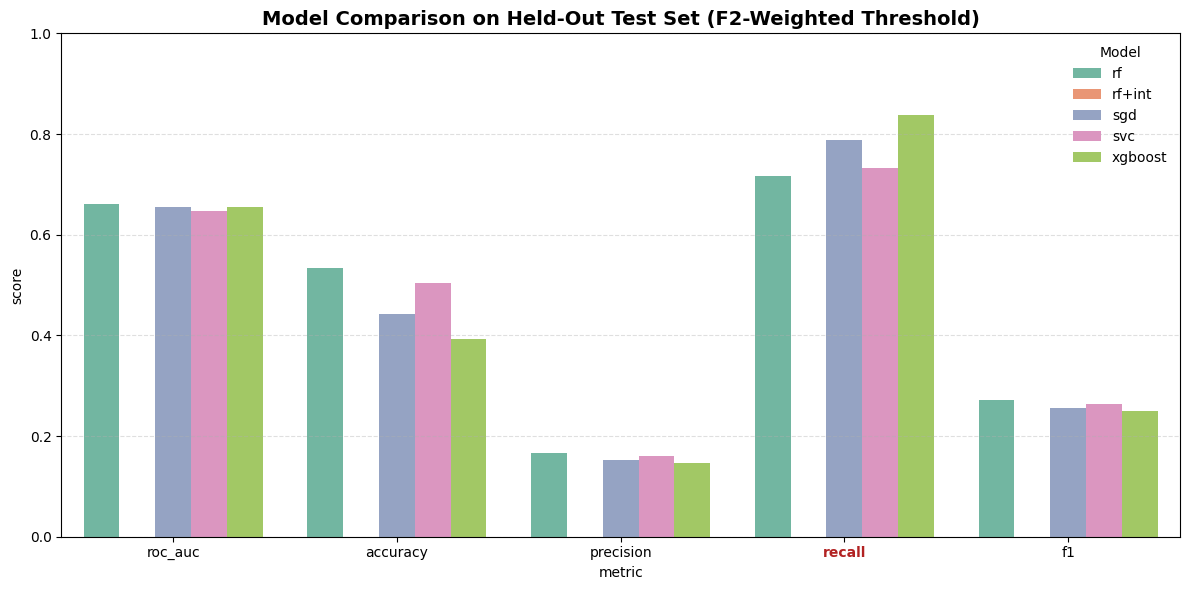

In [ ]:
# numeric metrics
metrics = ["roc_auc", "accuracy", "precision", "recall", "f1"]

# keep only the chosen id for duplicated test

df_filtered = filter_duplicates_by_id(df, keep_id=PLOT_ID)


# ensure model column sorted nicely for consistent colors
df_filtered["model"] = df_filtered["model"].astype("category")
model_order = sorted(df_filtered["model"].unique())
palette = sns.color_palette("Set2", len(model_order))



# melt for plotting
melted = df_filtered.melt(
    id_vars=["model", "data"],
    value_vars=metrics,
    var_name="metric",
    value_name="score"
)

# helper to make consistent chart layout
def plot_metrics(subset, title, emphasize=None):
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=subset,
        x="metric", y="score",
        hue="model",
        palette=palette,
        errorbar=None
    )
    plt.ylim(0, 1)
    plt.title(title, fontsize=14, weight="bold")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    if emphasize:
        plt.axhline(0, color="none") 
        # slightly bold recall bars
        bars = plt.gca().patches
        for b in bars:
            if b.get_x() < 0:  #type: ignore
                continue
        # recolor recall tick label
        xticks = plt.gca().get_xticklabels()
        for t in xticks:
            if t.get_text().lower() == emphasize.lower():
                t.set_weight("bold") #type: ignore
                t.set_color("#b22222")
    plt.legend(title="Model", frameon=False)
    plt.tight_layout()
    plt.show()


# --- Plot 1: Validation (pre-threshold) ---
validate_df = melted[melted["data"] == "validate"]
plot_metrics(validate_df,
             "Model Comparison on Validation Set (Pre-Threshold Testing)")

# --- Plot 2: Test (F2-weighted, recall-focused) ---
test_df = melted[melted["data"] == "test"]
plot_metrics(test_df,
             "Model Comparison on Held-Out Test Set (F2-Weighted Threshold)",
             emphasize="recall")

Pre-threshold 

In [ ]:
# compare pre and post log transform ROC_AUC for linear models
import numpy as np
df_sgd = df[(df['model'] == 'sgd') & ((df['data'] == 'validate') | (df['data'] == 'test'))]
df_svc = df[(df['model'] == 'svc') & ((df['data'] == 'validate') | (df['data'] == 'test'))]


#display(df_sgd.head())

pre_sgd = df_sgd[df_sgd['id'] == 0]
post_sgd = df_sgd[df_sgd['id'] == 1]

pre_svc = df_svc[df_svc['id'] == 0]
post_svc = df_svc[df_svc['id'] == 1]


roc_auc_sgd_p = np.mean(pre_sgd['roc_auc'])
roc_auc_svc_p = np.mean(pre_svc['roc_auc'])

roc_auc_sgd_a = np.mean(post_sgd['roc_auc'])
roc_auc_svc_a = np.mean(post_svc['roc_auc'])


print(f'ROC_AUC avg before log tranform |\tSGD: {roc_auc_sgd_p:.4f}\t|\tSVD: {roc_auc_svc_p:.4f}')
print(f'ROC_AUC avg after log tranform  |\tSGD: {roc_auc_sgd_a:.4f}\t|\tSVD: {roc_auc_svc_a:.4f}')


ROC_AUC avg before log tranform |	SGD: 0.6514	|	SVD: 0.6439
ROC_AUC avg after log tranform |	SGD: 0.6533	|	SVD: 0.6485
